In [ ]:
!pip install medmnist
!python -m medmnist available
!pip install torchlogix


MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/
All available datasets:
	pathmnist       | PathMNIST       | Size: 28 (default), 64, 128, 224.
	chestmnist      | ChestMNIST      | Size: 28 (default), 64, 128, 224.
	dermamnist      | DermaMNIST      | Size: 28 (default), 64, 128, 224.
	octmnist        | OCTMNIST        | Size: 28 (default), 64, 128, 224.
	pneumoniamnist  | PneumoniaMNIST  | Size: 28 (default), 64, 128, 224.
	retinamnist     | RetinaMNIST     | Size: 28 (default), 64, 128, 224.
	breastmnist     | BreastMNIST     | Size: 28 (default), 64, 128, 224.
	bloodmnist      | BloodMNIST      | Size: 28 (default), 64, 128, 224.
	tissuemnist     | TissueMNIST     | Size: 28 (default), 64, 128, 224.
	organamnist     | OrganAMNIST     | Size: 28 (default), 64, 128, 224.
	organcmnist     | OrganCMNIST     | Size: 28 (default), 64, 128, 224.
	organsmnist     | OrganSMNIST     | Size: 28 (default), 64, 128, 224.
	organmnist3d    | OrganMNIST3D    | Size: 28 (default), 64.
	nodule

In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')
ROOT = "/content/drive/MyDrive/Colab Notebooks/ConfLGN/MOC"
os.chdir(ROOT)

print("Current working directory:", os.getcwd())
!pip install -e ../torchlogix

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory: /content/drive/MyDrive/Colab Notebooks/ConfLGN/MOC
Obtaining file:///content/drive/MyDrive/Colab%20Notebooks/ConfLGN/torchlogix
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for torchlogix (pyproject.toml) ... done
  Created wheel for torchlogix: filename=torchlogix-0.1.1-0.editable-py3-none-any.whl size=5305 sha256=b078b320b9705f5d5747ecea65223a35f618ddf8a63c68ea78e8bd12e198316b
  Stored in directory: /tmp/pip-ephem-wheel-cache-d9btu_7s/wheels/cf/bf/dc/f5864c8cfbec5b2f942fd736ede23991967b0d80cbd239c9e3
Successfully built torchlogix
  Attempting uninstall: torchlogix
    Found existing installation: torchlogix 0.1.1
    Uninstalling torchlogix-0.1.1:
   

In [ ]:
  from pathlib import Path
  import sys

  from torchvision import transforms
  from medmnist import INFO, BloodMNIST
  import numpy as np

  PROJECT_ROOT = next(
      p for p in [Path.cwd(), *Path.cwd().parents]
      if (p / "MOC" / "utilities").exists()
  )

  if str(PROJECT_ROOT) not in sys.path:
      sys.path.insert(0, str(PROJECT_ROOT))

  from MOC.utilities.LogicNet import LogicNet
  from MOC.utilities.train_model import train_model
  transform = transforms.Compose([
      transforms.Grayscale(num_output_channels=1),  # LogicNet currently expects 1 channel
                     # LogicNet currently expects 28x28
      transforms.ToTensor(),
  ])

  target_transform = lambda y: int(np.asarray(y).item())
  num_classes = len(INFO["tissuemnist"]["label"])
  print(num_classes)
  train_dataset = BloodMNIST(
      split="train",
      transform=transform,
      target_transform=target_transform,
      download=True,
      size=28
  )
  test_dataset = BloodMNIST(
      split="test",
      transform=transform,
      target_transform=target_transform,
      download=True,
      size=28
  )


8


100%|██████████| 35.5M/35.5M [00:43<00:00, 824kB/s]


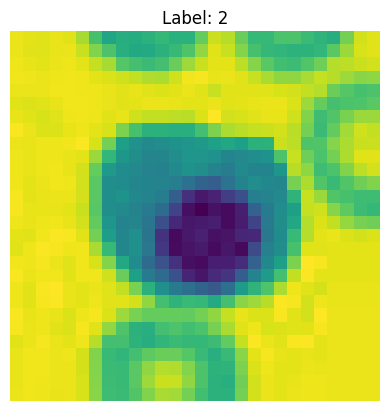

In [ ]:
import matplotlib.pyplot as plt

idx = 90  # numer obrazka z test setu

img, label = test_dataset[idx]

plt.imshow(img.squeeze())
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [ ]:
model = LogicNet(num_classes=num_classes,dense_num=4,base_dense_dims=[2048,1280,640,640], conv_num=3, kernel_multiplier=3, k=128,tau=20,channels=1)


In [ ]:
model, history = train_model(
        model,
        train_dataset,
        test_dataset,
        lr=2e-1,
        weight_decay=0,
        batch_size=256,
        num_iterations=5000,
        metrics_every=250,
        force_cpu=False,
    )

cuda
iter  250 | train_loss 5.2962 | test_acc_discrete 0.1692 | test_loss_discrete 7.1082 | test_acc_relaxed 0.1798 | test_loss_relaxed 3.5149
iter  500 | train_loss 2.9557 | test_acc_discrete 0.3560 | test_loss_discrete 6.7113 | test_acc_relaxed 0.3631 | test_loss_relaxed 3.0022
iter  750 | train_loss 1.7223 | test_acc_discrete 0.5989 | test_loss_discrete 1.2349 | test_acc_relaxed 0.5878 | test_loss_relaxed 1.0849
iter 1000 | train_loss 1.1692 | test_acc_discrete 0.5788 | test_loss_discrete 1.4344 | test_acc_relaxed 0.6080 | test_loss_relaxed 1.0652
iter 1250 | train_loss 1.0315 | test_acc_discrete 0.5776 | test_loss_discrete 1.2326 | test_acc_relaxed 0.6691 | test_loss_relaxed 0.9101
iter 1500 | train_loss 0.9186 | test_acc_discrete 0.7188 | test_loss_discrete 0.7976 | test_acc_relaxed 0.7287 | test_loss_relaxed 0.7452
iter 1750 | train_loss 0.7803 | test_acc_discrete 0.7407 | test_loss_discrete 0.7539 | test_acc_relaxed 0.7238 | test_loss_relaxed 0.7822
iter 2000 | train_loss 0.7154

In [ ]:
import torch
torch.save(model.state_dict(), 'logicnet_bloodmnist.pth')

NameError: name 'model' is not defined